<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_08_clasificacionLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 8: Clasificación logística

## Objetivo

Construir modelos de regresión logística para clasificación binaria y multiclase, interpretar probabilidades de salida, determinar fronteras de decisión y estudiar el efecto de la regularización sobre el desempeño del clasificador.

## Contexto matemático

La regresión logística modela la probabilidad de la clase positiva mediante la función sigmoide:$$\sigma(z) = \frac{1}{1+e^{-z}}, \quad z = \theta^T x$$Si $\sigma(z) \geq 0.5$, se asigna la clase 1; en caso contrario, la clase 0.La función de costo para $m$ ejemplos es la entropía cruzada:$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(h_\theta(x^{(i)})) + (1-y^{(i)}) \log(1-h_\theta(x^{(i)})) \right]$$La derivada respecto a $\theta_j$ conduce al gradiente que se usa en descenso del gradiente:$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left(h_\theta(x^{(i)}) - y^{(i)}\right) x_j^{(i)}$$Para clasificación multiclase, la versión multinomial aprende una distribución de probabilidades sobre todas las clases.

## Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_circles, load_iris
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.pipeline import Pipeline
import seaborn as sns

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

## Función sigmoide y probabilidad

La función sigmoide suaviza la salida lineal y la convierte en una probabilidad interpretable.

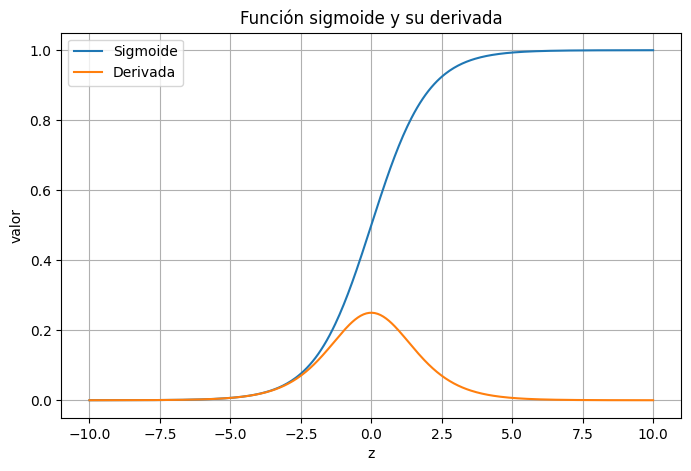

In [2]:
f = lambda x: 1 / (1 + np.exp(-x))
fp = lambda x: f(x) * (1 - f(x))
z = np.linspace(-10, 10, 400)

plt.figure(figsize=(8, 5))
plt.plot(z, f(z), label='Sigmoide')
plt.plot(z, fp(z), label='Derivada')
plt.xlabel('z')
plt.ylabel('valor')
plt.title('Función sigmoide y su derivada')
plt.legend()
plt.show()

## Parte 1: Clasificación binaria sintética

Construimos un conjunto de dos clases para estudiar la frontera de decisión y la interpretación probabilística del modelo.

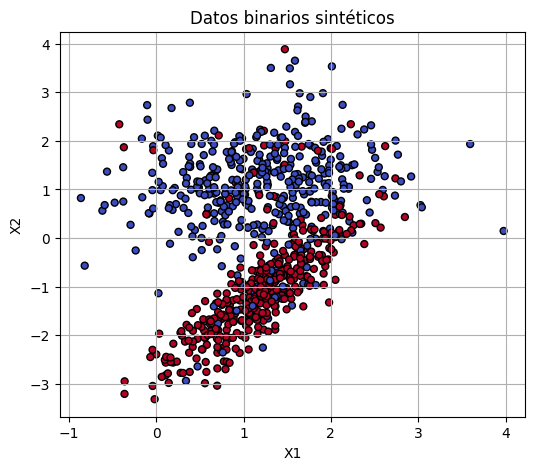

In [3]:
X1, y1 = make_classification(
    n_samples=800,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    flip_y=0.15,
    random_state=1
)

plt.figure(figsize=(6, 5))
plt.scatter(X1[:, 0], X1[:, 1], c=y1, cmap='coolwarm', edgecolor='k', s=25)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Datos binarios sintéticos')
plt.show()

In [4]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.25, random_state=42, stratify=y1
)

modelo_bin = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=3000, random_state=42))
])

modelo_bin.fit(X1_train, y1_train)
y1_pred = modelo_bin.predict(X1_test)
y1_prob = modelo_bin.predict_proba(X1_test)[:, 1]

acc_bin = accuracy_score(y1_test, y1_pred)
print(f'Accuracy binaria: {acc_bin:.4f}')
print()
print(classification_report(y1_test, y1_pred))

Accuracy binaria: 0.8650

              precision    recall  f1-score   support

           0       0.87      0.85      0.86        98
           1       0.86      0.88      0.87       102

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200



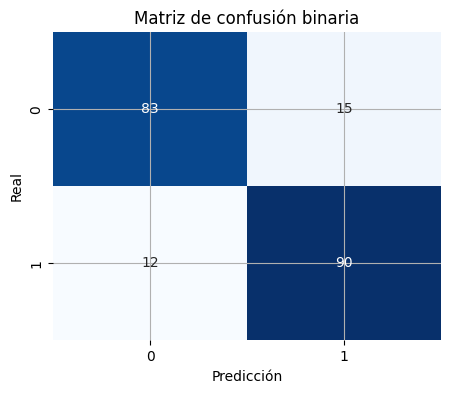

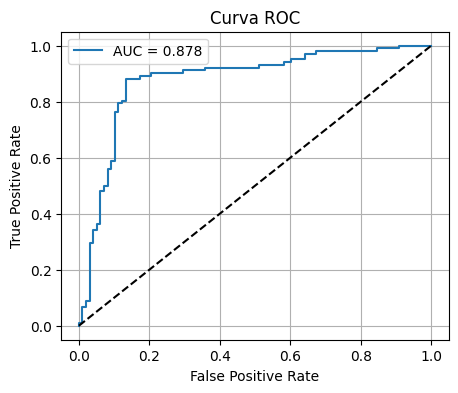

In [5]:
cm_bin = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusión binaria')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

fpr, tpr, _ = roc_curve(y1_test, y1_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

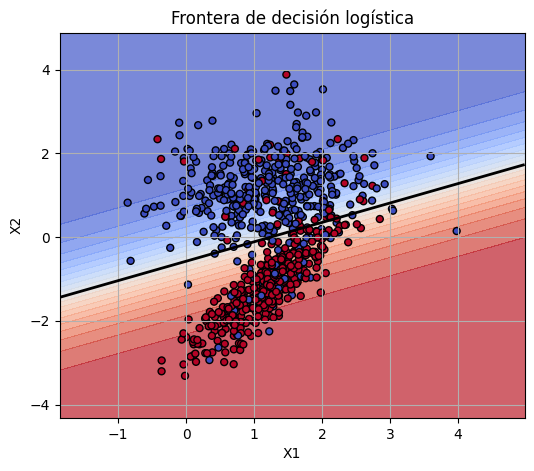

In [7]:
# Frontera de decisión
x_min, x_max = X1[:, 0].min() - 1, X1[:, 0].max() + 1
y_min, y_max = X1[:, 1].min() - 1, X1[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = modelo_bin.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.7)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X1[:, 0], X1[:, 1], c=y1, cmap='coolwarm', edgecolor='k', s=25)
plt.title('Frontera de decisión logística')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## Interpretación probabilística
En regresión logística, $P(y=1 \mid x)$ se interpreta directamente como la probabilidad de la clase positiva. El umbral 0.5 define la clase predicha, y la frontera de decisión corresponde al conjunto de puntos donde $\theta^T x = 0$.

## Parte 2: Frontera no lineal con make_circles

Cuando las clases no son separables linealmente, una transformación polinómica o un cambio de variables puede permitir una frontera más flexible. Aquí usamos `make_circles` para visualizar ese caso.

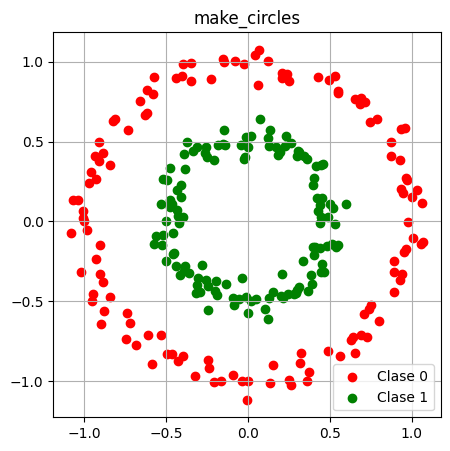

In [8]:
Xc, yc = make_circles(n_samples=250, factor=0.5, noise=0.05, random_state=0)
red = yc == 0
green = yc == 1

plt.figure(figsize=(5, 5))
plt.scatter(Xc[red, 0], Xc[red, 1], c='r', label='Clase 0')
plt.scatter(Xc[green, 0], Xc[green, 1], c='g', label='Clase 1')
plt.axis('tight')
plt.title('make_circles')
plt.legend()
plt.show()

In [9]:
# Transformación polinómica manual simple
Xc_poly = np.c_[Xc[:, 0], Xc[:, 1], Xc[:, 0]**2, Xc[:, 1]**2]
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc_poly, yc, test_size=0.25, random_state=42, stratify=yc
)

modelo_circles = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=3000, random_state=42))
])

modelo_circles.fit(Xc_train, yc_train)
yc_pred = modelo_circles.predict(Xc_test)
acc_circ = accuracy_score(yc_test, yc_pred)

print(f'Accuracy con frontera no lineal: {acc_circ:.4f}')
print()
print(classification_report(yc_test, yc_pred))

Accuracy con frontera no lineal: 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        31

    accuracy                           1.00        63
   macro avg       1.00      1.00      1.00        63
weighted avg       1.00      1.00      1.00        63



## Parte 3: Clasificación multiclase con Iris

En el conjunto Iris se debe resolver una clasificación de tres clases. Usamos la versión multinomial de regresión logística.

In [10]:
iris = load_iris()
X_i = iris.data
y_i = iris.target

print(iris.DESCR.splitlines()[0])
print('Dimensión:', X_i.shape)

df_example = np.c_[X_i, y_i]
print('Primeros cinco ejemplos:')
print(df_example[:5])

.. _iris_dataset:
Dimensión: (150, 4)
Primeros cinco ejemplos:
[[5.1 3.5 1.4 0.2 0. ]
 [4.9 3.  1.4 0.2 0. ]
 [4.7 3.2 1.3 0.2 0. ]
 [4.6 3.1 1.5 0.2 0. ]
 [5.  3.6 1.4 0.2 0. ]]


In [11]:
# Separación estratificada
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(X_i, y_i):
    X_train_i, X_test_i = X_i[train_index], X_i[test_index]
    y_train_i, y_test_i = y_i[train_index], y_i[test_index]

scaler_i = StandardScaler()
X_train_i = scaler_i.fit_transform(X_train_i)
X_test_i = scaler_i.transform(X_test_i)

modelo_iris = LogisticRegression(max_iter=5000, multi_class='multinomial', random_state=42)
modelo_iris.fit(X_train_i, y_train_i)

y_pred_i = modelo_iris.predict(X_test_i)
acc_i = accuracy_score(y_test_i, y_pred_i)

print(f'Accuracy multiclase Iris: {acc_i:.4f}')
print()
print(classification_report(y_test_i, y_pred_i, target_names=iris.target_names))

Accuracy multiclase Iris: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


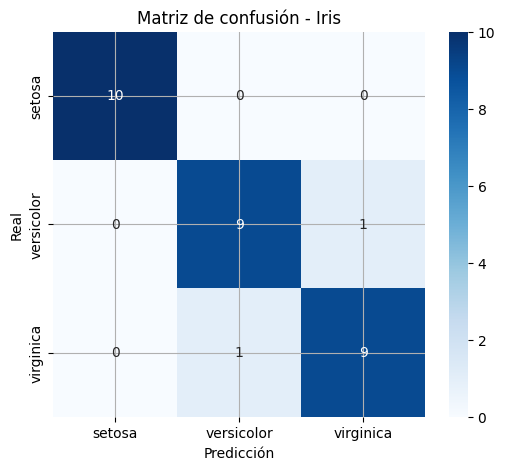

In [12]:
cm_i = confusion_matrix(y_test_i, y_pred_i)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Matriz de confusión - Iris')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [13]:
# Probabilidades para una flor concreta
X_new = np.array([[4.9, 5.0, 1.8, 0.3]])
X_new_scaled = scaler_i.transform(X_new)
prob_new = modelo_iris.predict_proba(X_new_scaled)[0]
pred_new = modelo_iris.predict(X_new_scaled)[0]

print('Probabilidades por clase:')
for nombre, prob in zip(iris.target_names, prob_new):
    print(f'{nombre}: {prob:.4f}')
print(f'Clase predicha: {iris.target_names[pred_new]}')

Probabilidades por clase:
setosa: 0.9998
versicolor: 0.0002
virginica: 0.0000
Clase predicha: setosa


## Regularización

La regularización controla la complejidad del modelo y ayuda a evitar sobreajuste. Compararemos diferentes valores de $C$, donde valores pequeños implican mayor regularización.

c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Biohealthy\Desktop\Universidad\Semestre 2026-1\Computacional_2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warnin

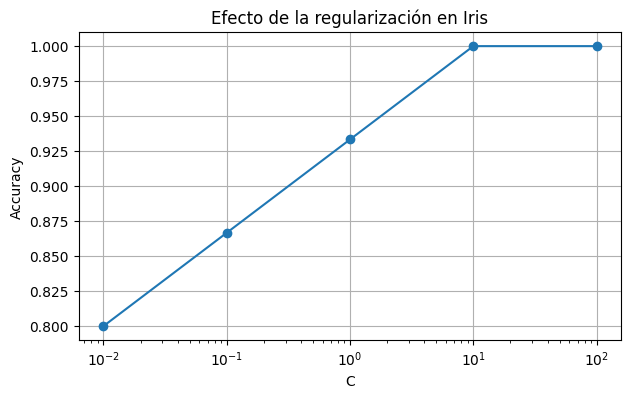

C=  0.01: accuracy=0.8000
C=   0.1: accuracy=0.8667
C=     1: accuracy=0.9333
C=    10: accuracy=1.0000
C=   100: accuracy=1.0000


In [14]:
valores_C = [0.01, 0.1, 1, 10, 100]
accuracies = []

for C in valores_C:
    modelo = LogisticRegression(max_iter=5000, multi_class='multinomial', C=C, random_state=42)
    modelo.fit(X_train_i, y_train_i)
    accuracies.append(accuracy_score(y_test_i, modelo.predict(X_test_i)))

plt.figure(figsize=(7, 4))
plt.plot(valores_C, accuracies, marker='o')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Efecto de la regularización en Iris')
plt.show()

for C, acc in zip(valores_C, accuracies):
    print(f'C={C:>6}: accuracy={acc:.4f}')

## Conclusiones

1. La regresión logística transforma una combinación lineal de variables en una probabilidad interpretable.
2. En clasificación binaria, la frontera de decisión corresponde al nivel 0.5 de la sigmoide.
3. En clasificación multiclase, la versión multinomial permite trabajar con más de dos clases de manera directa.
4. La regularización ayuda a estabilizar el modelo y reduce la probabilidad de sobreajuste.
5. Escalar las variables mejora la convergencia del optimizador y facilita la comparación entre atributos.